# QA — Reconciliation Metabase vs Adjust (CDS Android)

Notebook orchestration: gọi `clients/` để lấy data, gọi `reconciliation/` để xử lý.
Toàn bộ logic thật nằm trong 2 package đó — sửa logic ở đó, không sửa ở đây.

Đối chiếu đủ 12 chỉ số: ROAS D0-D28, Revenue D0-D28, Cost, Installs — sai số tương đối
thống nhất `ratio = mb/adj`, ngưỡng `config.THRESHOLD_PCT`. Cohort chưa đủ maturity theo
`Cohort Age` bị loại khỏi so sánh tự động.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import config
import run_config as rc
from clients.adjust_client import AdjustClient
from clients.metabase_client import MetabaseClient
from reconciliation.normalize import normalize_metabase, normalize_adjust, filter_excluded_dates
from reconciliation.merge import merge_sources, report_join_gaps
from reconciliation.flags import build_detail
from reconciliation.summary import summarize, top_discrepancy
from reconciliation import eda

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. (Tuỳ chọn) Override config riêng cho lần chạy này

`config.EXCLUDED_DATES` và `config.DATA_ASOF_DATE` là kiến thức riêng theo từng lần chạy
(ngày nào bị lỗi, chốt dữ liệu vào lúc nào) — override trực tiếp ở đây thay vì sửa `config.py`
nếu chỉ dùng cho 1 lần đối chiếu cụ thể.

In [4]:
game = config.GAMES[rc.GAME_KEY]
adjust_app_token = config.get_adjust_app_token(rc.GAME_KEY)
adjust_extra_params = config.get_adjust_extra_params(rc.GAME_KEY, rc.NETWORK_KEY)   # <-- đổi từ game["adjust_extra_params"]
metabase_network_value = config.get_metabase_network_value(rc.NETWORK_KEY)          # <-- mới

config.EXCLUDED_DATES = rc.EXCLUDED_DATES
config.DATA_ASOF_DATE = rc.DATA_ASOF_DATE

metabase_date_range = f"{rc.DATE_PERIOD_START}~{rc.DATE_PERIOD_END}"   # không dùng nữa, xem cell Metabase bên dưới
adjust_date_period = f"{rc.DATE_PERIOD_START}:{rc.DATE_PERIOD_END}"

print(f"Đang chạy cho: {game['label']} — network: {rc.NETWORK_KEY}")
print(f"Khoảng ngày: {rc.DATE_PERIOD_START} -> {rc.DATE_PERIOD_END}")

Đang chạy cho: Game C (BCE) — iOS — network: ['applovin', 'unity']
Khoảng ngày: 2026-08-01 -> 2026-09-17


## 1. Lấy dữ liệu Metabase

In [5]:
mb = MetabaseClient(base_url=config.METABASE_URL, api_key=config.METABASE_API_KEY)

parameters = mb.build_parameters(
    game["metabase_card_id"],
    date_from=rc.DATE_PERIOD_START,        # "2026-07-17" — plain date, không dùng dấu ~
    date_to=rc.DATE_PERIOD_END,
    network=metabase_network_value,        # "APPLOVIN" hoặc "UNITY" — 1 giá trị, không phải list
    game=game["metabase_game"],            # "Game A" — scalar, không phải ["Game A"]
    platform=game["metabase_platform"],    # "ANDROID" — scalar
)

df_mb = mb.query_card(game["metabase_card_id"], parameters)
print("Số dòng Metabase:", df_mb.shape[0])
df_mb.head()

Số dòng Metabase: 125


,Cohort Date,Game,Platform,Network,Campaign,Cost,Adjust Installs,CPI,ROAS D0,ROAS D3,...,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28,revenue_total_cal_d0,revenue_total_cal_d3,revenue_total_cal_d7,revenue_total_cal_d14,revenue_total_cal_d28,Revenue Complete Through
0,2026-09-17T00:00:00Z,Game C,IOS,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,6910.210064,1115,6.197498,0.110198,NaN,...,NaN,NaN,NaN,NaN,2.796,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
1,2026-09-17T00:00:00Z,Game C,IOS,UNITY,BCE iOS - D28 BLDROAS - 260701,1193.640595,442,2.700544,0.105676,NaN,...,NaN,NaN,NaN,NaN,0.000,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
2,2026-09-16T00:00:00Z,Game C,IOS,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,8139.752325,1187,6.857416,0.109294,NaN,...,NaN,NaN,NaN,NaN,7.508,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
3,2026-09-16T00:00:00Z,Game C,IOS,UNITY,BCE iOS - D28 BLDROAS - 260701,1158.671471,468,2.475794,0.146099,NaN,...,NaN,NaN,NaN,NaN,0.000,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
4,2026-09-15T00:00:00Z,Game C,IOS,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,6564.582947,897,7.318376,0.098830,0.192708,...,1265.046297,NaN,NaN,NaN,39.763,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z


## 2. Lấy dữ liệu Adjust
Dùng `config.ADJUST_METRICS_CDS_ANDROID` — đã gồm đủ Installs, Cost, ROAS D0-D28, Revenue D0-D28.

In [6]:
adjust = AdjustClient(api_token=config.ADJUST_API_TOKEN)

df_adjust, adjust_totals = adjust.fetch_report(
    app_token=adjust_app_token,
    dimensions=["day", "network", "campaign_network"],
    metrics=config.get_adjust_metrics(rc.GAME_KEY),
    date_period=adjust_date_period,
    extra_params=adjust_extra_params,   # <-- đổi từ game["adjust_extra_params"]
)

print("Số dòng Adjust:", df_adjust.shape[0])
print("Totals:", adjust_totals)
df_adjust.head()

Số dòng Adjust: 125
Totals: {'installs': 118677.0, 'network_cost': 499542.4262, 'roas_cal_d0': 0.0942, 'roas_cal_d3': 0.2011, 'roas_cal_d7': 0.2684, 'roas_cal_d14': 0.3373, 'roas_cal_d28': 0.4266, 'ad_revenue_total_cal_d0': 45601.8976, 'ad_revenue_total_cal_d3': 94350.6159, 'ad_revenue_total_cal_d7': 113496.316, 'ad_revenue_total_cal_d14': 117114.0785, 'ad_revenue_total_cal_d28': 60477.562, 'revenue_total_cal_d0': 1434.389, 'revenue_total_cal_d3': 6122.523, 'revenue_total_cal_d7': 11206.32, 'revenue_total_cal_d14': 15591.37, 'revenue_total_cal_d28': 15521.362}


,day,network,campaign_network,installs,network_cost,roas_cal_d0,roas_cal_d3,roas_cal_d7,roas_cal_d14,roas_cal_d28,ad_revenue_total_cal_d0,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28,revenue_total_cal_d0,revenue_total_cal_d3,revenue_total_cal_d7,revenue_total_cal_d14,revenue_total_cal_d28
0,2026-09-01,Unity,BCE iOS - D28 BLDROAS - 260701,4782,8614.6871,0.0882,0.2016,0.2646,0.3383,0.0,754.9953,1661.0499,2186.9973,2792.6797,0.0,4.794,75.461,92.567,121.522,0.0
1,2026-08-30,Unity,BCE iOS - D28 BLDROAS - 260701,4456,9206.5478,0.0919,0.1756,0.2412,0.3224,0.0,842.4562,1608.569,2185.4229,2850.9978,0.0,3.909,7.894,35.246,117.228,0.0
2,2026-08-27,Unity,BCE iOS - D28 BLDROAS - 260701,4056,8607.4785,0.0928,0.1886,0.2492,0.3146,0.0,791.4412,1571.9885,2057.5364,2537.3719,0.0,7.016,51.696,87.477,170.964,0.0
3,2026-08-31,Unity,BCE iOS - D28 BLDROAS - 260701,4051,8282.2249,0.0951,0.1862,0.2457,0.314,0.0,776.7082,1516.5763,1964.4906,2483.7238,0.0,10.625,25.772,70.656,117.289,0.0
4,2026-09-04,Unity,BCE iOS - D28 BLDROAS - 260701,3905,7196.7793,0.0963,0.2029,0.2557,0.3057,0.0,690.1859,1442.0712,1816.0542,2160.5356,0.0,2.742,18.448,24.448,39.294,0.0


## 3. Normalize + loại ngày lỗi + Merge

In [7]:
mb_norm = normalize_metabase(df_mb)
adj_norm = normalize_adjust(df_adjust)

mb_norm = filter_excluded_dates(mb_norm, config.EXCLUDED_DATES)
adj_norm = filter_excluded_dates(adj_norm, config.EXCLUDED_DATES)

merged = merge_sources(mb_norm, adj_norm)
join_stats = report_join_gaps(merged)


Khớp cả 2 nguồn: 125 dòng
Chỉ có ở Metabase: 0 dòng
Chỉ có ở Adjust: 0 dòng


## 4. Tính bảng đối chiếu chi tiết (long-format)
Mỗi dòng = 1 cohort x 1 metric. Dùng `merged` đầy đủ (kể cả phần lệch join key) —
các dòng đó tự ra flag "N/A (thiếu dữ liệu)", không bị âm thầm bỏ qua.

In [8]:
metric_map = config.get_metric_map(rc.GAME_KEY)
detail = build_detail(merged, metric_map)
detail.head(10)

Cohort Age tính theo DATA_ASOF_DATE = 2026-09-17
EXCLUDE_IMMATURE_COHORTS = True
[CHỐT] Sai số tương đối ratio = mb/adj. Ngưỡng Discrepancy: |rel_diff_pct| > 5.0%

Bảng detail: 2125 dòng (= 125 cohort x 17 chỉ số)
Số dòng bị loại vì cohort chưa đủ maturity: 339


,cohort_date,network,campaign,metric,cohort_age_days,is_immature,mb_value,adjust_value,abs_diff,ratio,rel_diff_pct,flag
0,2026-08-01,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,AD_REVENUE_D0,47,False,864.417854,864.4179,-0.000046,1.000000,-0.0000,OK
1,2026-08-01,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D0,47,False,154.462098,154.4621,-0.000002,1.000000,-0.0000,OK
2,2026-08-01,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D0,47,False,21.985958,21.9860,-0.000042,0.999998,-0.0002,OK
3,2026-08-01,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,AD_REVENUE_D14,47,False,2653.200252,2668.4261,-15.225848,0.994294,-0.5706,OK
4,2026-08-01,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D14,47,False,484.343282,491.7613,-7.418018,0.984915,-1.5085,OK
5,2026-08-01,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D14,47,False,107.115683,107.1157,-0.000017,1.000000,-0.0000,OK
6,2026-08-01,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,AD_REVENUE_D28,47,False,3161.584463,3189.1560,-27.571537,0.991355,-0.8645,OK
7,2026-08-01,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D28,47,False,709.365584,717.4968,-8.131216,0.988667,-1.1333,OK
8,2026-08-01,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D28,47,False,109.278248,109.2783,-0.000052,1.000000,-0.0000,OK
9,2026-08-01,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,AD_REVENUE_D3,47,False,1805.769108,1808.0477,-2.278592,0.998740,-0.1260,OK


## 5. Tổng hợp % Discrepancy — theo Campaign x Metric, và toàn hệ thống

In [9]:
summary_result = summarize(detail)
summary_by_campaign = summary_result["by_campaign"]
summary_overall = summary_result["overall"]


=== Tổng hợp theo từng Campaign ===
                                  campaign          metric  n_valid  mean_abs_diff  mean_ratio  mean_abs_rel_diff_pct  median_abs_rel_diff_pct  p90_abs_rel_diff_pct  pct_discrepancy
            BCE iOS - D28 BLDROAS - 260701         ROAS_D0       48         0.0001      0.9993                 0.0940                   0.0318                0.1303           0.0000
            BCE iOS - D28 BLDROAS - 260701         ROAS_D3       45         0.0009      0.9958                 0.4193                   0.0998                1.1515           0.0000
            BCE iOS - D28 BLDROAS - 260701         ROAS_D7       41         0.0020      0.9925                 0.7536                   0.3372                1.6442           2.4390
            BCE iOS - D28 BLDROAS - 260701        ROAS_D14       34         0.0033      0.9902                 1.0195                   0.6215                2.3066           2.9412
            BCE iOS - D28 BLDROAS - 260701        ROAS

In [10]:
print([c for c in merged.columns if "ad_revenue" in c or "revenue_total" in c])

['ad_revenue_total_cal_d0_mb', 'ad_revenue_total_cal_d3_mb', 'ad_revenue_total_cal_d7_mb', 'ad_revenue_total_cal_d14_mb', 'ad_revenue_total_cal_d28_mb', 'revenue_total_cal_d0_mb', 'revenue_total_cal_d3_mb', 'revenue_total_cal_d7_mb', 'revenue_total_cal_d14_mb', 'revenue_total_cal_d28_mb', 'ad_revenue_total_cal_d0_adj', 'ad_revenue_total_cal_d3_adj', 'ad_revenue_total_cal_d7_adj', 'ad_revenue_total_cal_d14_adj', 'ad_revenue_total_cal_d28_adj', 'revenue_total_cal_d0_adj', 'revenue_total_cal_d3_adj', 'revenue_total_cal_d7_adj', 'revenue_total_cal_d14_adj', 'revenue_total_cal_d28_adj']


## 6. Top các dòng lệch nhiều nhất — ưu tiên kiểm tra trước

In [11]:
top = top_discrepancy(detail, top_n=20, per_campaign=5)

print("=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===")
display(top["top_overall"])

print("\n=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===")
display(top["top_per_campaign"])


=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
416,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D28,40.746199,93.6968,-52.950601,-56.5127
452,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D28,0.304818,0.7009,-0.396082,-56.5105
449,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D14,0.284827,0.5825,-0.297673,-51.1026
413,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D14,38.073937,77.8599,-39.785963,-51.0994
422,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D7,36.164558,72.4304,-36.265842,-50.0699
458,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D7,0.270543,0.5418,-0.271257,-50.0658
467,2026-08-10,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D28,14.005017,26.9097,-12.904683,-47.9555
503,2026-08-10,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D28,0.194970,0.3746,-0.179630,-47.9525
371,2026-08-08,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D7,19.763404,32.9102,-13.146796,-39.9475
407,2026-08-08,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D7,0.343929,0.5727,-0.228771,-39.9460



=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
517,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D28,351.855725,377.9174,-26.061675,-6.8961
553,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,ROAS_D28,0.543138,0.5811,-0.037962,-6.5328
523,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D7,211.221125,223.9067,-12.685575,-5.6656
514,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D14,302.626048,320.0596,-17.433552,-5.4470
520,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D3,166.763282,176.0663,-9.303018,-5.2838
416,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D28,40.746199,93.6968,-52.950601,-56.5127
452,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D28,0.304818,0.7009,-0.396082,-56.5105
449,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D14,0.284827,0.5825,-0.297673,-51.1026
413,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D14,38.073937,77.8599,-39.785963,-51.0994
422,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D7,36.164558,72.4304,-36.265842,-50.0699


## 7. (Tuỳ chọn) Xuất kết quả
Thêm cell ghi `detail`/`summary_by_campaign`/`summary_overall` ra BigQuery / Google Sheets /
`.docx` report tại đây, khi bạn đã sẵn sàng nối vào pipeline output hiện có.

```python
# detail.to_csv("../outputs/reconciliation_detail.csv", index=False, encoding="utf-8-sig")
# summary_by_campaign.to_csv("../outputs/reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
# summary_overall.to_csv("../outputs/reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")
```

In [12]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

detail.to_csv(output_dir / "reconciliation_detail.csv", index=False, encoding="utf-8-sig")
summary_by_campaign.to_csv(output_dir / "reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
summary_overall.to_csv(output_dir / "reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")

df_mb.to_csv(output_dir / "mb.csv", index=False, encoding="utf-8-sig")
df_adjust.to_csv(output_dir / "adj.csv", index=False, encoding="utf-8-sig")

print(f"Đã xuất kết quả vào: {output_dir.resolve()}")

Đã xuất kết quả vào: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_c_ios


## 8. EDA — Phân tích trực quan

### 8.1. So sánh Tổng — Metabase vs Adjust
Tổng Cost/Installs/Revenue D0-D28 cộng dồn trên toàn bộ khoảng ngày đã chọn. Không gồm ROAS
(là tỷ lệ, cộng dồn không có ý nghĩa) — xem xu hướng ROAS ở mục 8.5.

=== So sánh TỔNG (cộng dồn toàn bộ khoảng ngày) ===
           metric      mb_total  adjust_total   n  rel_diff_pct
    AD_REVENUE_D0  45579.959395    45601.8976 125 -4.810810e-02
    AD_REVENUE_D3  88674.004366    88997.5565 119 -3.635517e-01
    AD_REVENUE_D7 104141.133911   104807.3255 111 -6.356346e-01
   AD_REVENUE_D14 100633.748447   101442.1656  97 -7.969242e-01
   AD_REVENUE_D28  48365.158373    48868.3204  60 -1.029628e+00
   IAP_REVENUE_D0   1434.389000     1434.3890  87  0.000000e+00
   IAP_REVENUE_D3   5745.930000     5745.9300  92  0.000000e+00
   IAP_REVENUE_D7  10243.194000    10243.1940  90  0.000000e+00
  IAP_REVENUE_D14  14773.130000    14773.1300  76  0.000000e+00
  IAP_REVENUE_D28  13560.166000    13560.1660  45  0.000000e+00
             COST 499542.427817   499542.4261 125  3.437145e-07
         INSTALLS 118559.000000   118677.0000 125 -9.942954e-02
 TOTAL_REVENUE_D0  43949.925676    43965.8687  87 -3.626227e-02
 TOTAL_REVENUE_D3  91686.694710    91976.6848  92 -3

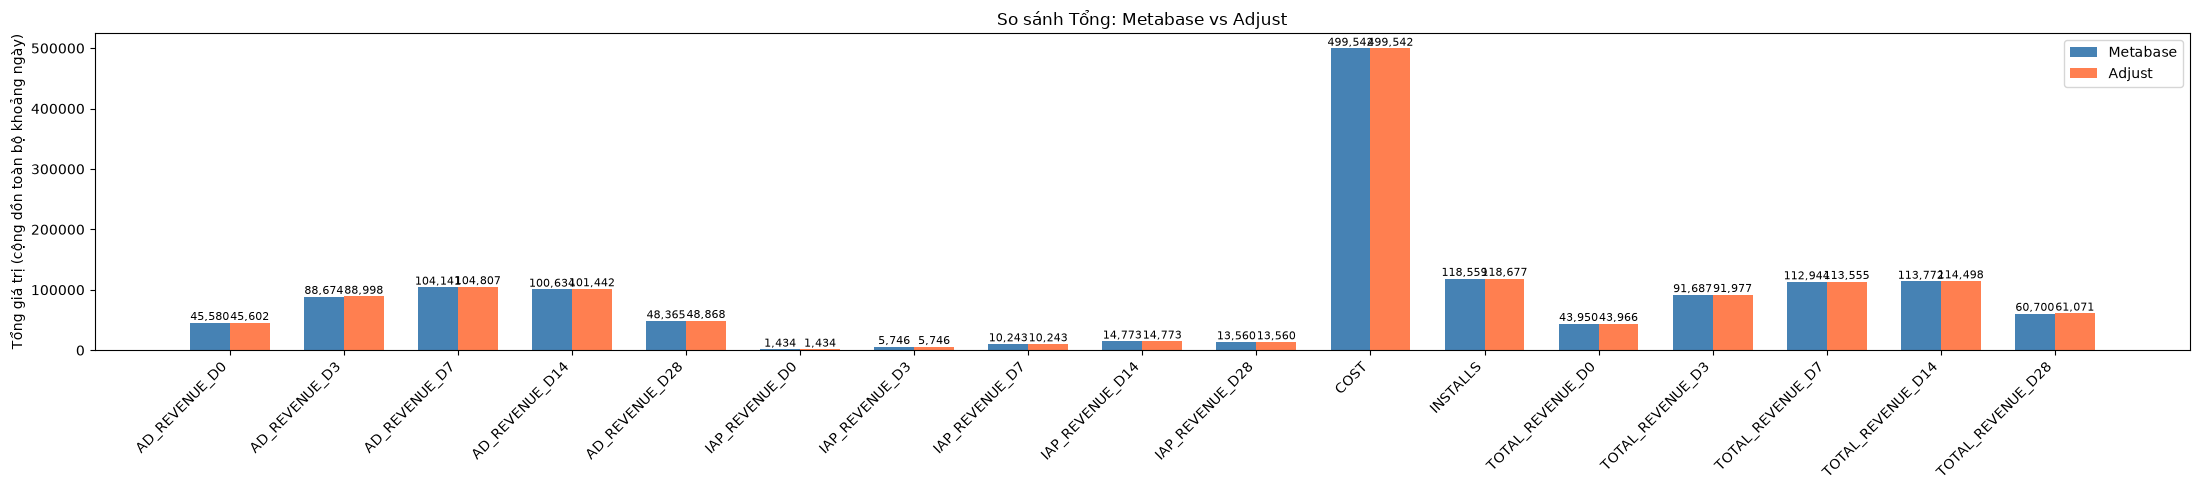

Đã lưu: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_c_ios\reconciliation_totals_comparison.csv


In [13]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

totals = eda.compare_totals(detail)
eda.plot_totals_comparison(totals)


print(f"Đã lưu: {(output_dir / 'reconciliation_totals_comparison.csv').resolve()}")

In [14]:
import reconciliation.eda as eda
print(eda.SUMMABLE_METRICS)

['COST', 'INSTALLS', 'AD_REVENUE_D0', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'IAP_REVENUE_D0', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28']


In [15]:
print(sorted(detail["metric"].unique()))

['AD_REVENUE_D0', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'COST', 'IAP_REVENUE_D0', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'INSTALLS', 'ROAS_D0', 'ROAS_D14', 'ROAS_D28', 'ROAS_D3', 'ROAS_D7']


### 8.2. Tổng quan Campaign
Số lượng Campaign đang đối chiếu, và số ngày (cohort) mỗi Campaign có dữ liệu — giúp phát hiện
nhanh Campaign nào có mẫu quá nhỏ, cần cẩn trọng khi đọc % Discrepancy.

Số lượng Campaign đang đối chiếu: 3
                                            n_days  first_date   last_date
campaign                                                                  
BCE iOS - D28 BLDROAS - 260701                  48  2026-08-01  2026-09-17
BCE iOS - D28 BLDROAS - Main tier - 260506      48  2026-08-01  2026-09-17
BCE iOS - D7 BLDROAS - 260701                   29  2026-08-01  2026-08-30


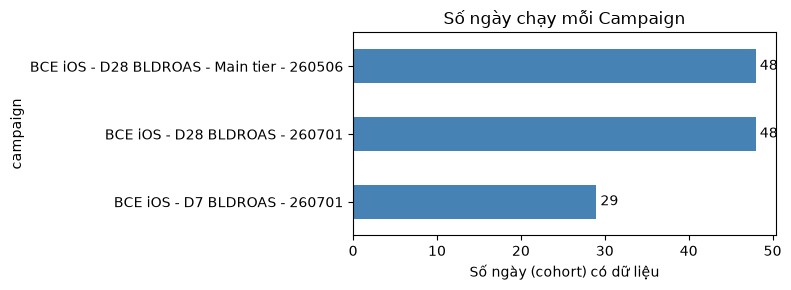

In [16]:
campaign_overview_df = eda.campaign_overview(detail)
eda.plot_campaign_overview(campaign_overview_df)

### 8.3. Heatmap % Discrepancy theo Campaign x Metric
Màu càng đỏ đậm, % Discrepancy càng cao — nhìn nhanh Campaign nào và Metric nào đang có vấn đề.

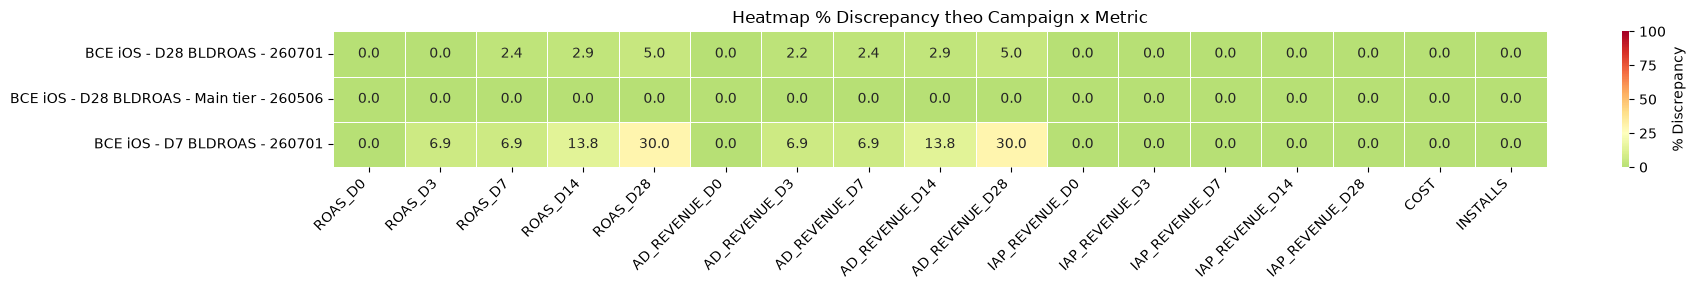

In [17]:
discrepancy_pivot = eda.plot_discrepancy_heatmap(summary_by_campaign)

### 8.4. Phân tích theo Metric — toàn hệ thống (gộp mọi Campaign)

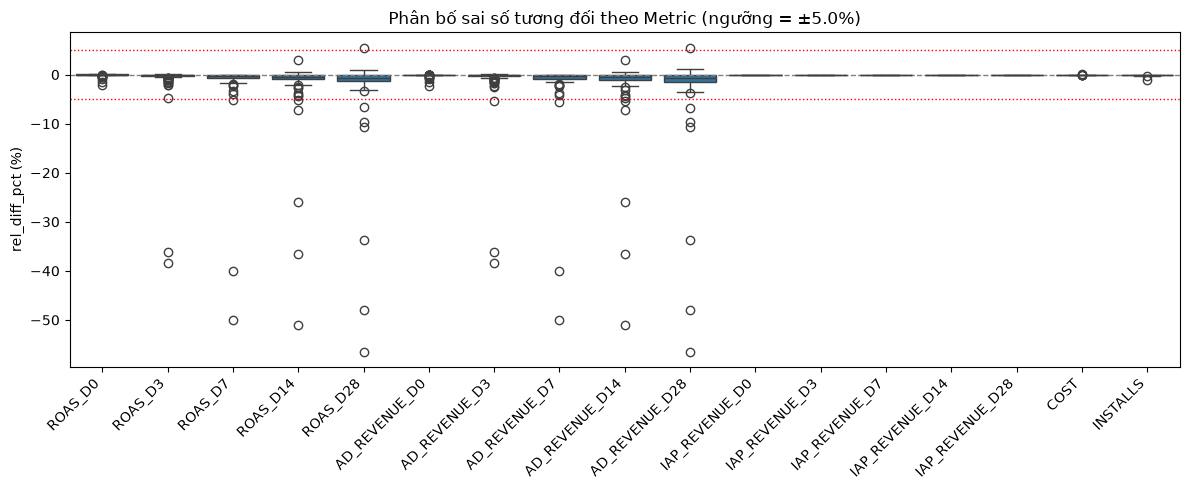

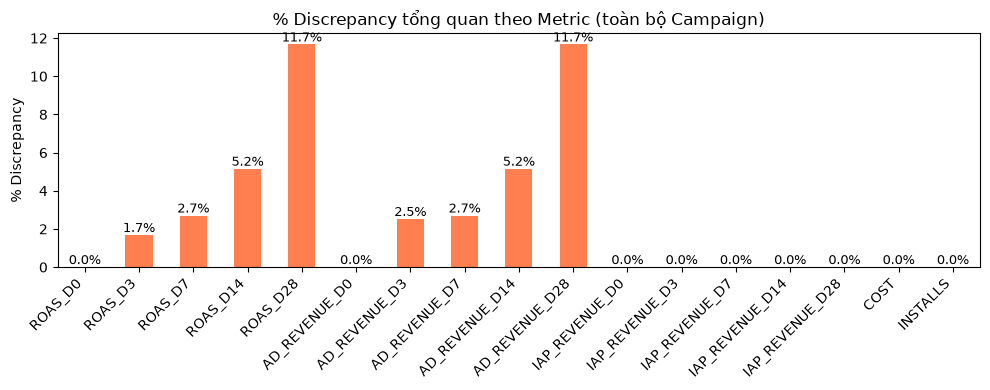

In [18]:
eda.plot_rel_diff_boxplot(detail)
eda.plot_overall_discrepancy_bar(summary_overall)

### 8.5. Xu hướng theo thời gian
- **Total**: trung bình `ratio = mb/adj` mỗi ngày, gộp tất cả campaign, cho vài metric đại diện.
- **Theo Campaign**: 1 đường/campaign, cho ĐÚNG 1 metric (đổi `metric=...` để xem chỉ số khác).

Đường `ratio = 1` (nét đứt) là khớp hoàn toàn.

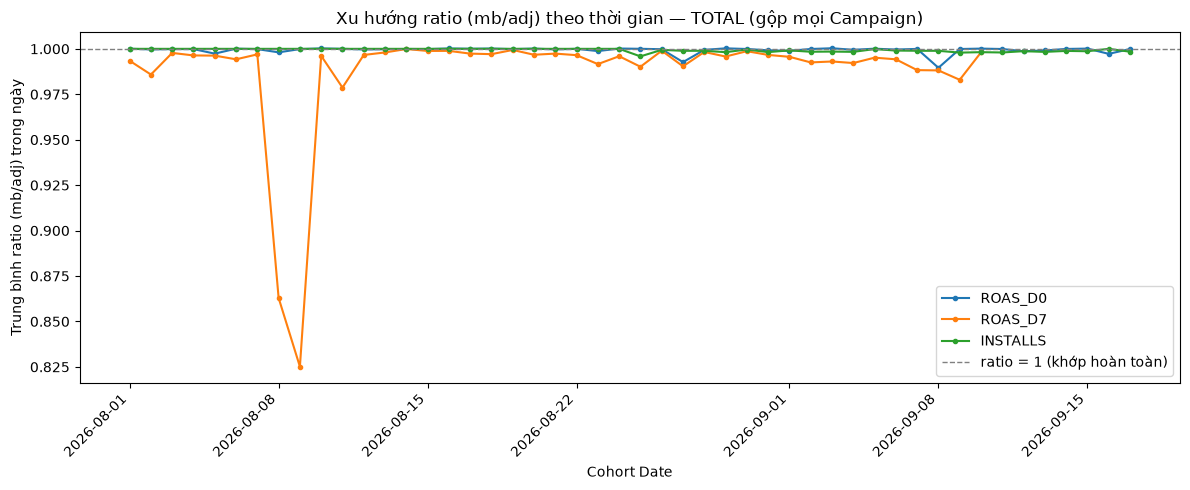

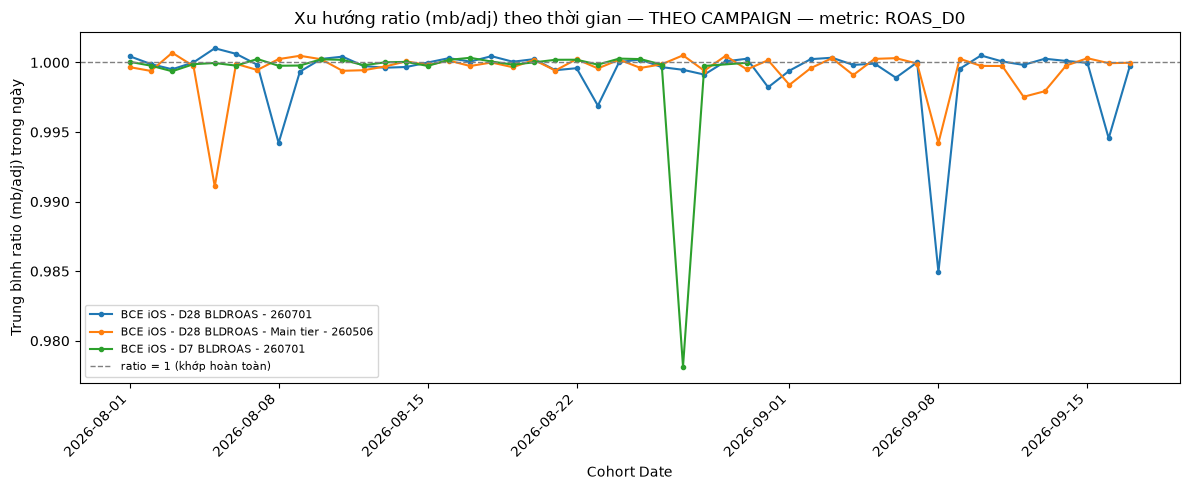

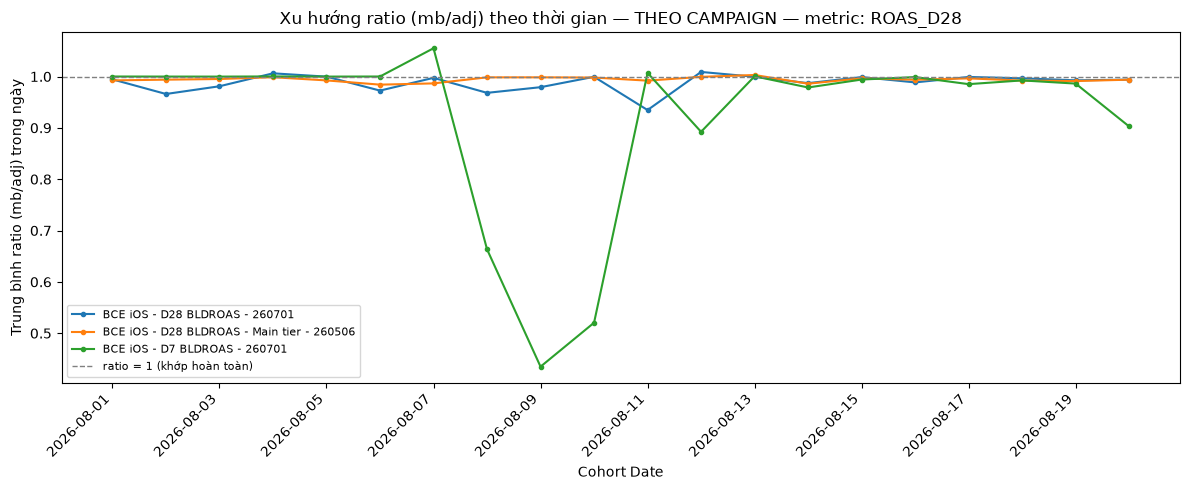

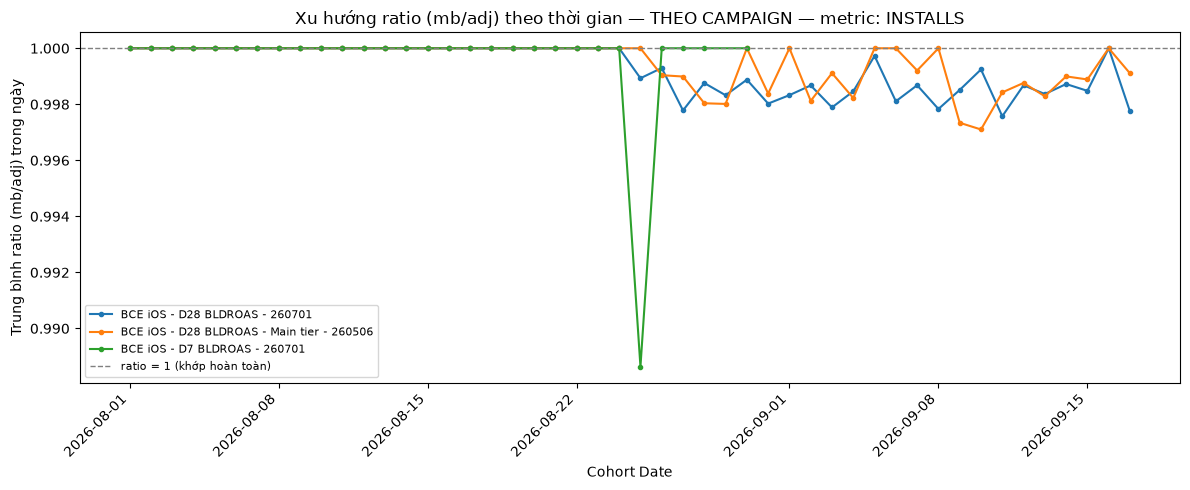

In [19]:
# Total — gộp mọi campaign
eda.plot_ratio_trend(detail, metrics=["ROAS_D0", "REVENUE_D0", "ROAS_D7", "REVENUE_D7", "INSTALLS"])

# Theo từng Campaign — đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D0")
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D28")
eda.plot_ratio_trend_by_campaign(detail, metric="INSTALLS")

### 8.7. Phân bố sai số tương đối — Histogram & ECDF
- **Histogram (tất cả Campaign)**: 1 ô/metric, thấy hình dạng phân bố thật (lệch, đa đỉnh...).
- **Histogram theo Campaign**: 1 ô/campaign, cho 1 metric cụ thể — phát hiện campaign nào
  gây lệch phân bố chung.
- **ECDF**: trả lời trực tiếp "bao nhiêu % cohort đạt ngưỡng ±5%?" — đọc tại giao điểm với
  đường ngưỡng đỏ.

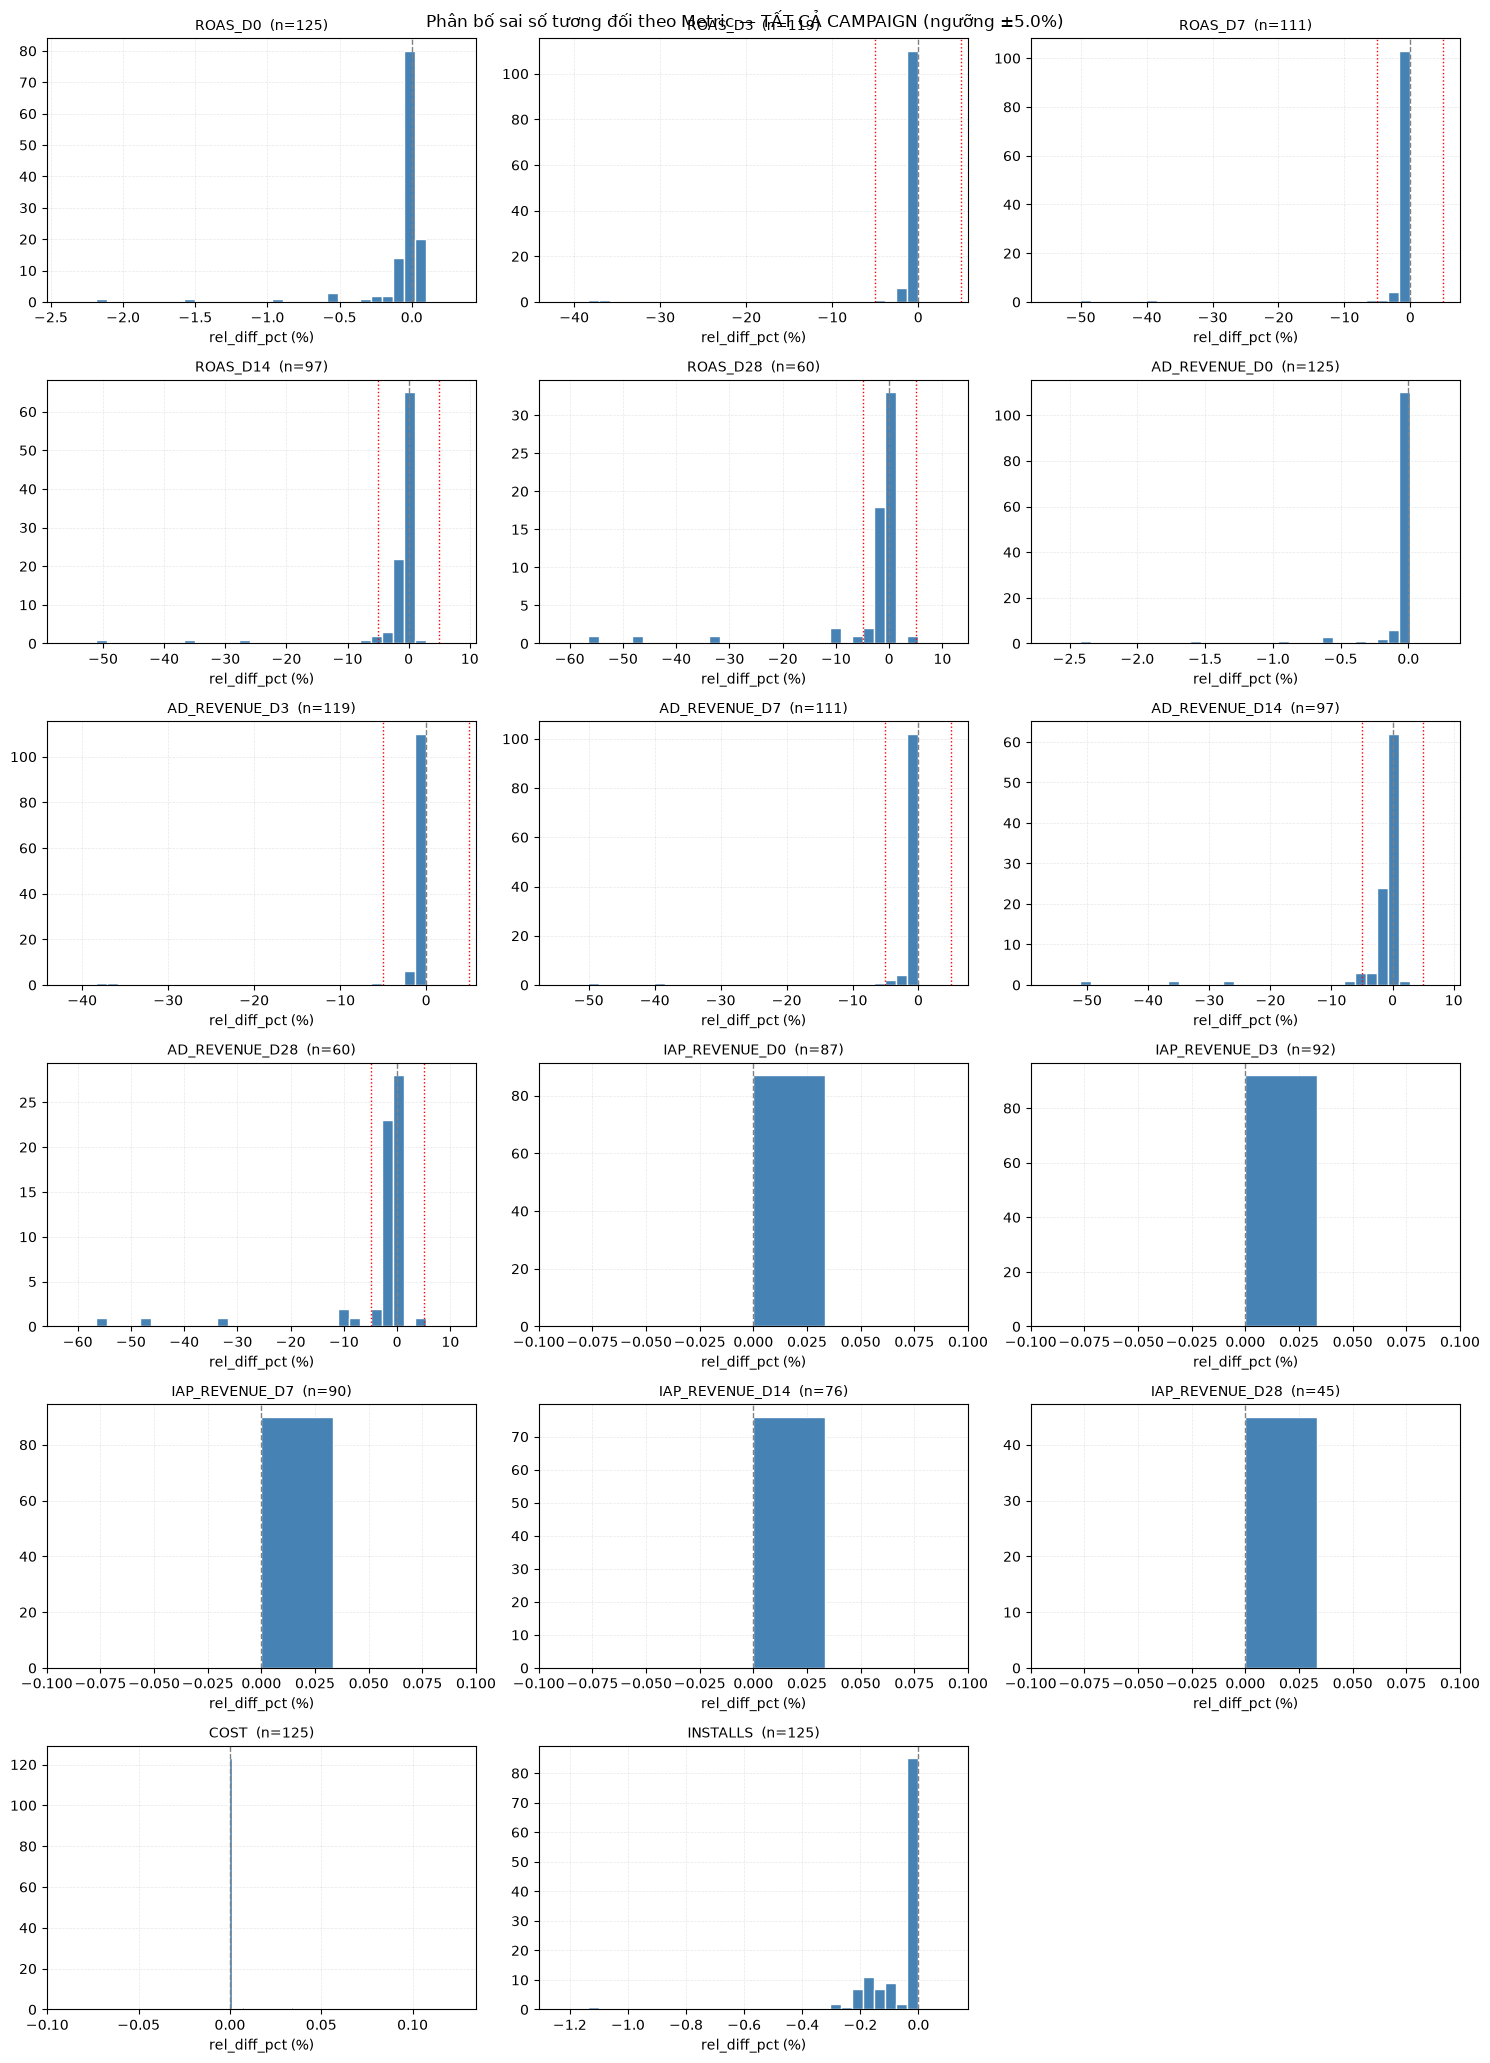

In [20]:
eda.plot_rel_diff_histogram(detail)

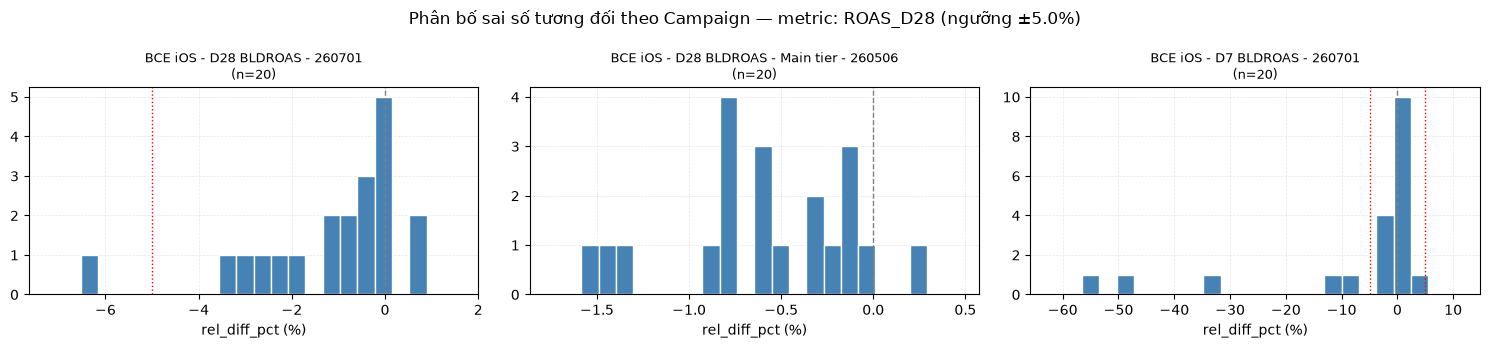

In [21]:
# Đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_rel_diff_histogram_by_campaign(detail, metric="ROAS_D28")

In [22]:
eda.plot_rel_diff_histogram_for_campaign(detail, campaign="BCE Android - D28 AdROAS - 260813")

⚠️ Không tìm thấy dữ liệu hợp lệ cho campaign 'BCE Android - D28 AdROAS - 260813'. Kiểm tra lại tên campaign (VD: sorted(detail['campaign'].unique())).


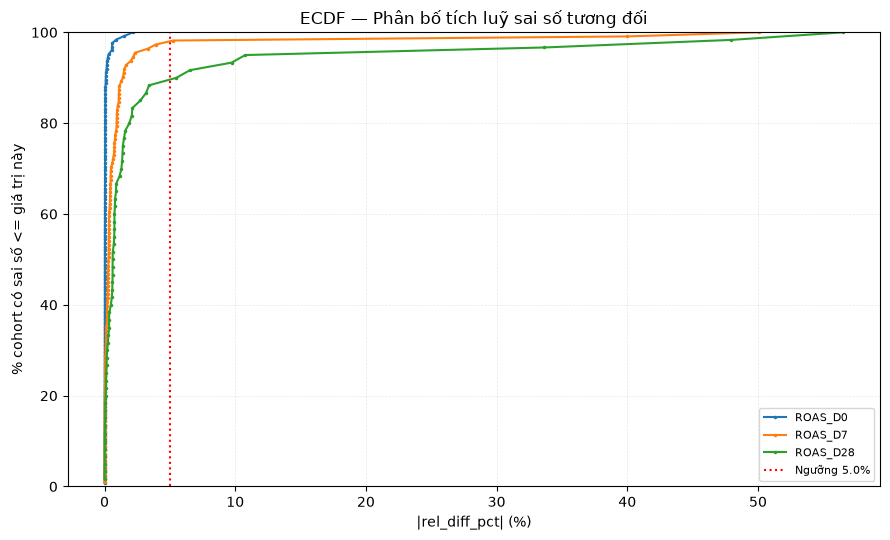

=== % cohort đạt ngưỡng (|rel_diff_pct| <= THRESHOLD_PCT) ===
  metric   n  pct_within_threshold
 ROAS_D0 125                 100.0
 ROAS_D7 111                  97.3
ROAS_D28  60                  88.3


In [23]:
pct_within_df = eda.plot_rel_diff_ecdf(detail, metrics=["ROAS_D0", "ROAS_D7", "ROAS_D28", "REVENUE_D0"])

In [24]:
from reconciliation.summary import iap_mismatches

iap_diff = iap_mismatches(detail)
print(f"{len(iap_diff)} dòng (cohort x metric) có IAP khác nhau")
iap_diff.to_csv(output_dir / "iap_mismatches.csv", index=False, encoding="utf-8-sig")
iap_diff


0 dòng (cohort x metric) có IAP khác nhau


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct,flag
